# Experiment 4 — Is large-`N` recovery limited by primitive exposure?

The completed five-seed sweep in Experiment 3 held the total SAE training budget fixed at
`T = 128M` examples. Because every example contains one uniformly selected `x`
primitive and one uniformly selected `y` primitive, the expected number of
training examples containing each named primitive is

$$K = \frac{T}{N}. $$

The nearly perfect `N=8` condition had `K = 128M / 8 = 16M`, whereas the
declining `N=256` condition had only `K = 128M / 256 = 0.5M`. This notebook
holds `N=256` fixed and increases `K`. The primary test gives `N=256` the same
`K=16M` exposure as `N=8`, requiring `T=4.096B` generated examples. Higher
values `K=24M` and `K=32M` test whether still more training restores true-feature recovery.


## What this experiment can establish

- If `N=256` recovery approaches the `N=8` reference at `K=16M`, the original
  decline was substantially caused by insufficient training exposure per primitive.
- If recovery improves only above `K=16M`, larger SAEs require more exposure per
  primitive than the small successful model.
- If recovery plateaus well below the reference even at larger `K`, additional
  training budget alone does not explain the large-`N` decline.

**Scope limitation:** increasing `K` increases both fresh generated samples and
optimizer steps. It therefore tests total training exposure, not unique-data budget
and optimization steps separately. A later control would compare fresh samples
against repeated passes over a fixed activation buffer at the same step count.

Matching `K` also does not match exposure per composed pair. Under independent
uniform sampling, an individual pair occurs `T/N² = K/N` times on average. At
`K=16M`, this is 2M occurrences per pair for `N=8` but only 62,500 for `N=256`.


In [1]:
from __future__ import annotations

import json
import sys
from collections.abc import Iterator, Sequence
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F
from scipy.optimize import linear_sum_assignment
from tqdm.auto import tqdm


WORKING_DIR = Path.cwd().resolve()
if (WORKING_DIR / 'sparse_factorial_generator.py').exists():
    EXPERIMENT_DIR = WORKING_DIR
elif (WORKING_DIR / 'composed-features' / 'sparse_factorial_generator.py').exists():
    EXPERIMENT_DIR = WORKING_DIR / 'composed-features'
else:
    raise FileNotFoundError(
        'Run from the repository root or composed-features directory.'
    )

if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

from sae_lens import StandardTrainingSAE, StandardTrainingSAEConfig
from sae_lens.config import LoggingConfig, SAETrainerConfig
from sae_lens.training.sae_trainer import SAETrainer

from sparse_factorial_generator import FactorialConfig, SparseFactorialGenerator
from toy_model import default_device


DEVICE = default_device()
ARTIFACT_ROOT = EXPERIMENT_DIR / 'artifacts' / '04_fixed_primitive_exposure'
CHECKPOINT_ROOT = ARTIFACT_ROOT / 'sae_trajectories'
RESULTS_ROOT = ARTIFACT_ROOT / 'results'
for path in (CHECKPOINT_ROOT, RESULTS_ROOT):
    path.mkdir(parents=True, exist_ok=True)

print('Experiment directory:', EXPERIMENT_DIR)
print('Device:', DEVICE)
print('Artifact root:', ARTIFACT_ROOT)


Experiment directory: /Users/abdulhakeemadefioye/Desktop/SAE/composed-features
Device: mps
Artifact root: /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/04_fixed_primitive_exposure


## Experimental constants and exposure milestones

The full experiment keeps the Experiment 3 setup fixed: `N=256`, activation
dimension 256, 512 SAE latents, uniform independent feature identities, perfectly
correlated pair amplitudes, no singleton examples, and SAE seed 0. Experiment 3
showed very small seed-to-seed variance at `N=256`, so this experiment uses one
trajectory to concentrate compute on substantially larger training budgets.

Milestones are evaluated along one continuous training trajectory. The curve starts
at half the successful `N=8` exposure and reaches twice that exposure. Checkpoints
contain SAE weights, optimizer
state, scheduler state, and generator RNG state, so interrupted runs can resume.


In [11]:
N_PER_SET = 256
ACTIVATION_DIM = 256
D_SAE = 2 * N_PER_SET
TRAIN_BATCH_SIZE = 1_024
LEARNING_RATE = 3e-4
L1_COEFFICIENT = 0.3
ADAM_BETA1 = 0.0
ADAM_BETA2 = 0.999
DICTIONARY_SEED = 0
DATA_SEED = 0
SAE_SEED = 0
EVAL_SEED = 10_000
EVAL_SAMPLES = 65_536

# K is the expected number of training examples containing each named primitive.
K_VALUES = (8_000_000, 16_000_000, 24_000_000, 32_000_000)

# The full run is extremely expensive. QUICK_MODE only checks the pipeline.
QUICK_MODE = False
QUICK_K_VALUES = (4_000, 8_000)

if QUICK_MODE:
    ACTIVE_K_VALUES = QUICK_K_VALUES
else:
    ACTIVE_K_VALUES = K_VALUES

assert tuple(sorted(set(ACTIVE_K_VALUES))) == ACTIVE_K_VALUES
for k in ACTIVE_K_VALUES:
    assert (k * N_PER_SET) % TRAIN_BATCH_SIZE == 0

print('Quick mode:', QUICK_MODE)
print('SAE seed:', SAE_SEED)
print('K milestones:', ACTIVE_K_VALUES)


Quick mode: False
SAE seed: 0
K milestones: (8000000, 16000000, 24000000, 32000000)


In [12]:
budget_table = pd.DataFrame(
    {
        'K_expected_samples_per_primitive': ACTIVE_K_VALUES,
        'training_samples_T': [k * N_PER_SET for k in ACTIVE_K_VALUES],
        'optimizer_steps': [
            k * N_PER_SET // TRAIN_BATCH_SIZE for k in ACTIVE_K_VALUES
        ],
        'expected_samples_per_pair': [
            k / N_PER_SET for k in ACTIVE_K_VALUES
        ],
        'relative_to_N8_K': [k / 16_000_000 for k in ACTIVE_K_VALUES],
    }
)
display(budget_table.style.format({
    'K_expected_samples_per_primitive': '{:,.0f}',
    'training_samples_T': '{:,.0f}',
    'optimizer_steps': '{:,.0f}',
    'expected_samples_per_pair': '{:,.1f}',
    'relative_to_N8_K': '{:.3g}×',
}))

# Exact full-run mapping for N=256:
# K=8M  -> T=2.048B samples -> 2,000,000 optimizer steps
# K=16M -> T=4.096B samples -> 4,000,000 optimizer steps
# K=24M -> T=6.144B samples -> 6,000,000 optimizer steps
# K=32M -> T=8.192B samples -> 8,000,000 optimizer steps

max_samples_per_seed = max(ACTIVE_K_VALUES) * N_PER_SET
max_steps_per_seed = max_samples_per_seed // TRAIN_BATCH_SIZE
print(f'Maximum samples in the trajectory: {max_samples_per_seed:,}')
print(f'Maximum optimizer steps in the trajectory: {max_steps_per_seed:,}')
print('This is the total for the single SAE trajectory.')


,K_expected_samples_per_primitive,training_samples_T,optimizer_steps,expected_samples_per_pair,relative_to_N8_K
0,"8,000,000","2,048,000,000","2,000,000","31,250.0",0.5×
1,"16,000,000","4,096,000,000","4,000,000","62,500.0",1×
2,"24,000,000","6,144,000,000","6,000,000","93,750.0",1.5×
3,"32,000,000","8,192,000,000","8,000,000","125,000.0",2×


Maximum samples in the trajectory: 8,192,000,000
Maximum optimizer steps in the trajectory: 8,000,000
This is the total for the single SAE trajectory.


## Fixed `N=256` antipodal data generator

This reproduces the Experiment 3 `N=256` dictionary exactly for dictionary seed 0.
Each factor set contains 128 antipodal axis pairs. The `x` and `y` axes occupy
orthogonal subspaces before a random orthogonal rotation. Every generated example
contains exactly one uniformly sampled `x` primitive and one uniformly sampled `y`
primitive with a shared amplitude.


In [13]:
def orthogonal_matrix(dim: int, seed: int) -> torch.Tensor:
    generator = torch.Generator(device='cpu').manual_seed(seed)
    matrix = torch.randn(dim, dim, generator=generator)
    q, r = torch.linalg.qr(matrix)
    signs = torch.where(torch.diag(r) >= 0, 1.0, -1.0)
    return q * signs.unsqueeze(0)


def make_antipodal_dictionary(
    n_per_set: int,
    *,
    seed: int,
    device: torch.device | str,
) -> torch.Tensor:
    if n_per_set <= 0 or n_per_set % 2:
        raise ValueError('Antipodal geometry requires a positive, even N.')

    half = n_per_set // 2
    dictionary = torch.zeros(2 * n_per_set, n_per_set)
    for axis in range(half):
        dictionary[2 * axis, axis] = 1.0
        dictionary[2 * axis + 1, axis] = -1.0

        y_offset = n_per_set
        y_axis = half + axis
        dictionary[y_offset + 2 * axis, y_axis] = 1.0
        dictionary[y_offset + 2 * axis + 1, y_axis] = -1.0

    return (dictionary @ orthogonal_matrix(n_per_set, seed)).to(device)


TRUE_DICTIONARY = make_antipodal_dictionary(
    N_PER_SET, seed=DICTIONARY_SEED, device=DEVICE
)


def build_generator(seed: int) -> SparseFactorialGenerator:
    return SparseFactorialGenerator(
        FactorialConfig(
            n_x=N_PER_SET,
            n_y=N_PER_SET,
            activation_dim=ACTIVATION_DIM,
            amplitude_correlation=1.0,
            singleton_probability=0.0,
            noise_std=0.0,
            seed=seed,
        ),
        device=str(DEVICE),
        true_dictionary=TRUE_DICTIONARY,
        normalize_dictionary=False,
    )


class SparseFactorialActivationIterator(Iterator[torch.Tensor]):
    def __init__(self, generator: SparseFactorialGenerator, batch_size: int):
        self.generator = generator
        self.batch_size = batch_size

    def __iter__(self):
        return self

    @torch.no_grad()
    def __next__(self) -> torch.Tensor:
        hidden, _ = self.generator.sample(self.batch_size)
        return hidden.detach()


unit_dictionary = F.normalize(TRUE_DICTIONARY, dim=1)
x_dictionary = unit_dictionary[:N_PER_SET]
y_dictionary = unit_dictionary[N_PER_SET:]
assert torch.allclose(x_dictionary[0::2], -x_dictionary[1::2], atol=2e-5)
assert torch.allclose(y_dictionary[0::2], -y_dictionary[1::2], atol=2e-5)
assert float((x_dictionary @ y_dictionary.T).abs().max()) < 2e-5
print('Verified fixed N=256 orthogonal-antipodal dictionary.')


Verified fixed N=256 orthogonal-antipodal dictionary.


## SAE and resumable trajectory training

All milestones for a seed belong to one continuous optimizer trajectory. This is a
paired learning-curve experiment: the decoder evaluated at a larger `K` is the same
SAE after additional training, not a new initialization. Different SAE seeds provide
independent trajectories.


In [14]:
def make_standard_sae(sae_seed: int) -> StandardTrainingSAE:
    torch.manual_seed(sae_seed)
    cfg = StandardTrainingSAEConfig(
        d_in=ACTIVATION_DIM,
        d_sae=D_SAE,
        device=str(DEVICE),
        dtype='float32',
        apply_b_dec_to_input=False,
        normalize_activations='none',
        l1_coefficient=L1_COEFFICIENT,
        lp_norm=1.0,
        l1_warm_up_steps=0,
        decoder_init_norm=1.0,
    )
    return StandardTrainingSAE(cfg).to(DEVICE)


def make_trainer(
    sae: StandardTrainingSAE,
    generator: SparseFactorialGenerator,
    *,
    total_training_samples: int,
) -> SAETrainer:
    cfg = SAETrainerConfig(
        total_training_samples=total_training_samples,
        train_batch_size_samples=TRAIN_BATCH_SIZE,
        lr=LEARNING_RATE,
        lr_end=LEARNING_RATE,
        lr_scheduler_name='constant',
        lr_warm_up_steps=0,
        lr_decay_steps=0,
        adam_beta1=ADAM_BETA1,
        adam_beta2=ADAM_BETA2,
        device=str(DEVICE),
        n_checkpoints=0,
        checkpoint_path=None,
        save_final_checkpoint=False,
        logger=LoggingConfig(
            log_to_wandb=False,
            eval_every_n_wandb_logs=2**31 - 1,
        ),
        n_batches_for_norm_estimate=1,
    )
    return SAETrainer(
        cfg=cfg,
        sae=sae,
        data_provider=SparseFactorialActivationIterator(
            generator, TRAIN_BATCH_SIZE
        ),
    )


def milestone_name(k: int) -> str:
    total = k * N_PER_SET
    return f'K{k:012d}__T{total:015d}'


def seed_checkpoint_root(sae_seed: int) -> Path:
    return CHECKPOINT_ROOT / f'N{N_PER_SET:04d}__sae-{sae_seed}'


def milestone_path(sae_seed: int, k: int) -> Path:
    return seed_checkpoint_root(sae_seed) / milestone_name(k)


def checkpoint_is_resumable(path: Path) -> bool:
    required = (
        'cfg.json',
        'sae_weights.safetensors',
        'trainer_state.pt',
        'activation_scaler.json',
        'generator_rng_state.pt',
    )
    return all((path / name).exists() for name in required)


def save_milestone(
    trainer: SAETrainer,
    generator: SparseFactorialGenerator,
    *,
    sae_seed: int,
    k: int,
) -> Path:
    root = seed_checkpoint_root(sae_seed)
    root.mkdir(parents=True, exist_ok=True)
    name = milestone_name(k)
    trainer.save_checkpoint(checkpoint_name=name, base_path=root)
    path = root / name
    torch.save(generator.rng.get_state(), path / 'generator_rng_state.pt')
    metadata = {
        'n_per_set': N_PER_SET,
        'activation_dim': ACTIVATION_DIM,
        'd_sae': D_SAE,
        'sae_seed': sae_seed,
        'dictionary_seed': DICTIONARY_SEED,
        'data_seed': DATA_SEED,
        'k_expected_samples_per_primitive': k,
        'training_samples': k * N_PER_SET,
        'training_steps': trainer.n_training_steps,
        'batch_size': TRAIN_BATCH_SIZE,
        'lr': LEARNING_RATE,
        'l1_coefficient': L1_COEFFICIENT,
    }
    (path / 'experiment_spec.json').write_text(
        json.dumps(metadata, indent=2) + '\n'
    )
    return path


def initialize_or_resume_trajectory(
    sae_seed: int,
    k_values: Sequence[int],
) -> tuple[SAETrainer, SparseFactorialGenerator, int | None]:
    generator = build_generator(DATA_SEED)
    completed_k = [
        k for k in k_values if checkpoint_is_resumable(milestone_path(sae_seed, k))
    ]
    latest_k = max(completed_k, default=None)
    max_total = max(k_values) * N_PER_SET

    if latest_k is None:
        sae = make_standard_sae(sae_seed)
        trainer = make_trainer(
            sae, generator, total_training_samples=max_total
        )
        return trainer, generator, None

    checkpoint = milestone_path(sae_seed, latest_k)
    sae = StandardTrainingSAE.load_from_disk(
        checkpoint, device=str(DEVICE), dtype='float32'
    ).to(DEVICE)
    trainer = make_trainer(sae, generator, total_training_samples=max_total)
    trainer.load_trainer_state(checkpoint)
    generator_state = torch.load(
        checkpoint / 'generator_rng_state.pt', map_location='cpu'
    )
    generator.rng.set_state(generator_state)
    expected_samples = latest_k * N_PER_SET
    if trainer.n_training_samples != expected_samples:
        raise ValueError(
            f'Resumed {trainer.n_training_samples:,} samples; '
            f'expected {expected_samples:,}.'
        )
    return trainer, generator, latest_k


def ensure_seed_trajectory(sae_seed: int, k_values: Sequence[int]) -> None:
    trainer, generator, latest_k = initialize_or_resume_trajectory(
        sae_seed, k_values
    )
    pending = [k for k in k_values if latest_k is None or k > latest_k]
    if not pending:
        print(f'SAE seed {sae_seed}: all milestones already complete.')
        return

    pbar = tqdm(
        total=max(k_values) * N_PER_SET,
        initial=trainer.n_training_samples,
        desc=f'SAE seed {sae_seed}',
    )
    for k in pending:
        target_samples = k * N_PER_SET
        while trainer.n_training_samples < target_samples:
            trainer.maybe_reset_sparsity()
            trainer.step(next(trainer.data_provider))
            trainer.n_training_steps += 1
            pbar.update(TRAIN_BATCH_SIZE)
        if trainer.n_training_samples != target_samples:
            raise RuntimeError('A K milestone was not batch-aligned.')
        path = save_milestone(
            trainer, generator, sae_seed=sae_seed, k=k
        )
        print(f'\nSaved K={k:,}: {path}')
    pbar.close()

    del trainer
    if DEVICE.type == 'mps':
        torch.mps.empty_cache()
    elif DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


## Recovery and training-quality metrics

The primary outcomes match Experiment 3: one-to-one Hungarian primitive recovery
at cosine 0.90 and MMCS. The notebook also records evaluation FVU, mean SAE `L0`,
and the fraction of latents that never activate on
the fresh evaluation batch. High reconstruction quality with persistently poor
primitive recovery would indicate an alternative learned dictionary rather than
simple failure to fit the activation distribution.


In [15]:
@torch.no_grad()
def primitive_recovery_metrics(
    sae: StandardTrainingSAE, dictionary: torch.Tensor
) -> dict[str, float]:
    decoder = F.normalize(sae.W_dec.detach().float(), dim=1)
    primitives = F.normalize(dictionary.detach().float(), dim=1)
    similarity = primitives @ decoder.T

    mmcs = float(similarity.max(dim=1).values.mean())
    primitive_rows, decoder_cols = linear_sum_assignment(
        -similarity.detach().cpu().numpy()
    )
    assigned = similarity[
        torch.as_tensor(primitive_rows, device=similarity.device),
        torch.as_tensor(decoder_cols, device=similarity.device),
    ]
    return {
        'hungarian_90': float((assigned >= 0.90).float().mean()),
        'mmcs': mmcs,
        'hungarian_assigned_cosine_mean': float(assigned.mean()),
        'hungarian_assigned_cosine_min': float(assigned.min()),
    }


@torch.no_grad()
def training_quality_metrics(sae: StandardTrainingSAE) -> dict[str, float]:
    evaluation_generator = build_generator(EVAL_SEED)
    hidden, _ = evaluation_generator.sample(EVAL_SAMPLES)
    feature_acts = sae.encode(hidden)
    reconstructed = sae.decode(feature_acts)

    squared_error = (hidden - reconstructed).pow(2).sum()
    total_variance = (hidden - hidden.mean(dim=0)).pow(2).sum()
    fired = feature_acts > 0
    return {
        'eval_fvu': float(squared_error / total_variance),
        'eval_mean_l0': float(fired.sum(dim=1).float().mean()),
        'eval_mean_l1': float(feature_acts.abs().sum(dim=1).mean()),
        'eval_dead_latent_fraction': float((~fired.any(dim=0)).float().mean()),
    }


RESULT_COLUMNS = [
    'n_per_set',
    'sae_seed',
    'dictionary_seed',
    'data_seed',
    'k_expected_samples_per_primitive',
    'training_samples',
    'optimizer_steps',
    'expected_samples_per_pair',
    'hungarian_90',
    'mmcs',
    'hungarian_assigned_cosine_mean',
    'hungarian_assigned_cosine_min',
    'eval_fvu',
    'eval_mean_l0',
    'eval_mean_l1',
    'eval_dead_latent_fraction',
]


def evaluate_saved_milestones(
    sae_seeds: Sequence[int],
    k_values: Sequence[int],
    output_path: Path,
) -> pd.DataFrame:
    rows = []
    for sae_seed in sae_seeds:
        for k in k_values:
            checkpoint = milestone_path(sae_seed, k)
            if not checkpoint_is_resumable(checkpoint):
                raise FileNotFoundError(f'Incomplete checkpoint: {checkpoint}')
            sae = StandardTrainingSAE.load_from_disk(
                checkpoint, device=str(DEVICE), dtype='float32'
            ).to(DEVICE)
            row = {
                'n_per_set': N_PER_SET,
                'sae_seed': sae_seed,
                'dictionary_seed': DICTIONARY_SEED,
                'data_seed': DATA_SEED,
                'k_expected_samples_per_primitive': k,
                'training_samples': k * N_PER_SET,
                'optimizer_steps': k * N_PER_SET // TRAIN_BATCH_SIZE,
                'expected_samples_per_pair': k / N_PER_SET,
                **primitive_recovery_metrics(sae, TRUE_DICTIONARY),
                **training_quality_metrics(sae),
            }
            rows.append(row)
            pd.DataFrame(rows)[RESULT_COLUMNS].to_csv(output_path, index=False)
            print(
                f'Evaluated seed={sae_seed}, K={k:,}: '
                f'H90={row["hungarian_90"]:.4f}, MMCS={row["mmcs"]:.4f}'
            )
            del sae
            if DEVICE.type == 'mps':
                torch.mps.empty_cache()
            elif DEVICE.type == 'cuda':
                torch.cuda.empty_cache()

    return (
        pd.DataFrame(rows)[RESULT_COLUMNS]
        .sort_values(['k_expected_samples_per_primitive', 'sae_seed'])
        .reset_index(drop=True)
    )


## Run the experiment

Set `RUN_EXPERIMENT=True` deliberately. For a pipeline check, first set
`QUICK_MODE=True` and rerun the configuration cell. For the full experiment,
`QUICK_MODE=False` requires 8.192B samples and 8M optimizer steps for the single
SAE seed. Because milestones share one continuous trajectory, those values
are totals, not costs that must be added together.


In [16]:
RUN_EXPERIMENT = True

run_label = 'quick' if QUICK_MODE else 'full_K8m_to_K32m'
results_path = RESULTS_ROOT / f'fixed_exposure_{run_label}.csv'

if RUN_EXPERIMENT:
    print(f'Running one continuous trajectory with SAE seed {SAE_SEED}.')
    ensure_seed_trajectory(SAE_SEED, ACTIVE_K_VALUES)
    results = evaluate_saved_milestones(
        (SAE_SEED,), ACTIVE_K_VALUES, results_path
    )
elif results_path.exists():
    results = pd.read_csv(results_path)
    print('Loaded', results_path)
else:
    results = None
    print(
        'No saved results yet. Set RUN_EXPERIMENT=True after reviewing the '
        'budget table.'
    )

if results is not None:
    display(results)


Running one continuous trajectory with SAE seed 0.


SAE seed 0:   0%|          | 0/8192000000 [00:00<?, ?it/s]


Saved K=8,000,000: /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/04_fixed_primitive_exposure/sae_trajectories/N0256__sae-0/K000008000000__T000002048000000

Saved K=16,000,000: /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/04_fixed_primitive_exposure/sae_trajectories/N0256__sae-0/K000016000000__T000004096000000

Saved K=24,000,000: /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/04_fixed_primitive_exposure/sae_trajectories/N0256__sae-0/K000024000000__T000006144000000

Saved K=32,000,000: /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/04_fixed_primitive_exposure/sae_trajectories/N0256__sae-0/K000032000000__T000008192000000
Evaluated seed=0, K=8,000,000: H90=0.8965, MMCS=0.9070
Evaluated seed=0, K=16,000,000: H90=0.8965, MMCS=0.9070
Evaluated seed=0, K=24,000,000: H90=0.8965, MMCS=0.9070
Evaluated seed=0, K=32,000,000: H90=0.8965, MMCS=0.9070


,n_per_set,sae_seed,dictionary_seed,data_seed,k_expected_samples_per_primitive,training_samples,optimizer_steps,expected_samples_per_pair,hungarian_90,mmcs,hungarian_assigned_cosine_mean,hungarian_assigned_cosine_min,eval_fvu,eval_mean_l0,eval_mean_l1,eval_dead_latent_fraction
0,256,0,0,0,8000000,2048000000,2000000,31250.0,0.896484,0.906997,0.902968,-0.005547,0.150871,1.558441,0.176510,0.091797
1,256,0,0,0,16000000,4096000000,4000000,62500.0,0.896484,0.907029,0.903057,-0.004398,0.151201,1.545349,0.173918,0.099609
2,256,0,0,0,24000000,6144000000,6000000,93750.0,0.896484,0.907026,0.903107,-0.004923,0.151044,1.545731,0.174011,0.099609
3,256,0,0,0,32000000,8192000000,8000000,125000.0,0.896484,0.907042,0.903103,-0.004923,0.150824,1.545898,0.174135,0.099609


## Compact single-trajectory results

There is no cross-seed aggregation or confidence interval. This table retains the
four requested exposure milestones, their exact total sample budgets, Hungarian
recovery at the 0.90 cutoff, MMCS, and the training-quality diagnostics.


In [17]:
if results is not None:
    result_summary = results[[
        'k_expected_samples_per_primitive',
        'training_samples',
        'optimizer_steps',
        'hungarian_90',
        'mmcs',
        'eval_fvu',
        'eval_mean_l0',
        'eval_dead_latent_fraction',
    ]].sort_values('k_expected_samples_per_primitive')
    display(result_summary.style.format({
        'k_expected_samples_per_primitive': '{:,.0f}',
        'training_samples': '{:,.0f}',
        'optimizer_steps': '{:,.0f}',
        'hungarian_90': '{:.4f}',
        'mmcs': '{:.4f}',
        'eval_fvu': '{:.6f}',
        'eval_mean_l0': '{:.3f}',
        'eval_dead_latent_fraction': '{:.4f}',
    }))
else:
    result_summary = None


,k_expected_samples_per_primitive,training_samples,optimizer_steps,hungarian_90,mmcs,eval_fvu,eval_mean_l0,eval_dead_latent_fraction
0,"8,000,000","2,048,000,000","2,000,000",0.8965,0.9070,0.150871,1.558,0.0918
1,"16,000,000","4,096,000,000","4,000,000",0.8965,0.9070,0.151201,1.545,0.0996
2,"24,000,000","6,144,000,000","6,000,000",0.8965,0.9070,0.151044,1.546,0.0996
3,"32,000,000","8,192,000,000","8,000,000",0.8965,0.9070,0.150824,1.546,0.0996


## Recovery learning curves and `N=8` reference

The dashed reference lines show the completed Experiment 3 five-seed mean for the
`N=8`, `T=128M`, `K=16M` condition. The solid line is the single `N=256`, seed-0
training trajectory evaluated at the four requested exposure milestones.


N=8 reference: H90=0.9625, MMCS=0.9916
Saved /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/04_fixed_primitive_exposure/results/fixed_exposure_full_K8m_to_K32m_recovery_curves.png


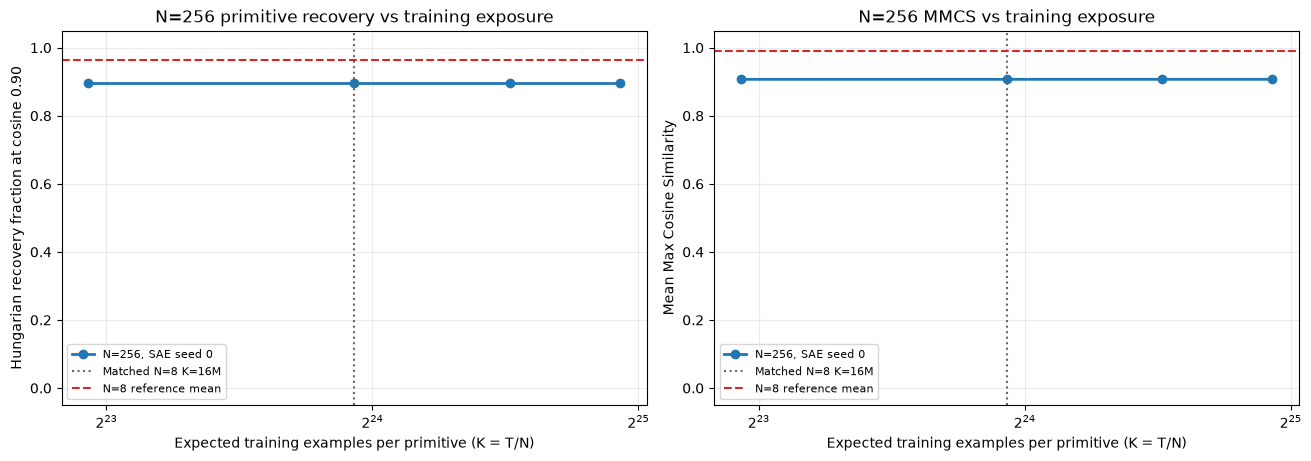

In [18]:
REFERENCE_PATH = (
    EXPERIMENT_DIR
    / 'artifacts'
    / '03_sparse_factorial_antipodal'
    / 'results'
    / 'n_primitive_recovery_128m_5_sae_seeds_aggregate.csv'
)

if not REFERENCE_PATH.exists():
    raise FileNotFoundError(f'Missing Experiment 3 reference: {REFERENCE_PATH}')
reference_frame = pd.read_csv(REFERENCE_PATH)
n8_reference = reference_frame.loc[reference_frame['n_per_set'] == 8].iloc[0]
print(
    'N=8 reference:',
    f'H90={n8_reference["hungarian_90_mean"]:.4f},',
    f'MMCS={n8_reference["mmcs_mean"]:.4f}',
)


def plot_learning_curve(
    ax,
    frame: pd.DataFrame,
    *,
    metric: str,
    title: str,
    ylabel: str,
    reference_mean: float,
) -> None:
    ordered = frame.sort_values('k_expected_samples_per_primitive')
    ax.plot(
        ordered['k_expected_samples_per_primitive'],
        ordered[metric],
        marker='o',
        linewidth=2,
        label='N=256, SAE seed 0',
    )
    ax.axvline(
        16_000_000, color='0.4', linestyle=':', label='Matched N=8 K=16M'
    )
    ax.axhline(
        reference_mean, color='C3', linestyle='--', label='N=8 reference mean'
    )
    ax.set_xscale('log', base=2)
    ax.set(
        title=title,
        xlabel='Expected training examples per primitive (K = T/N)',
        ylabel=ylabel,
        ylim=(-0.05, 1.05),
    )
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)


if results is not None:
    figure, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
    plot_learning_curve(
        axes[0],
        results,
        metric='hungarian_90',
        title='N=256 primitive recovery vs training exposure',
        ylabel='Hungarian recovery fraction at cosine 0.90',
        reference_mean=float(n8_reference['hungarian_90_mean']),
    )
    plot_learning_curve(
        axes[1],
        results,
        metric='mmcs',
        title='N=256 MMCS vs training exposure',
        ylabel='Mean Max Cosine Similarity',
        reference_mean=float(n8_reference['mmcs_mean']),
    )
    plot_path = RESULTS_ROOT / f'fixed_exposure_{run_label}_recovery_curves.png'
    figure.savefig(plot_path, dpi=200, bbox_inches='tight')
    print('Saved', plot_path)
    plt.show()


## Interpretation checklist

1. **Lower exposure point:** `K=8M` corresponds to `T=2.048B`, half the successful
   `N=8` exposure per primitive.
2. **Primary matched-exposure test:** compare `N=256, K=16M` (`T=4.096B`) against the five-seed
   `N=8, K=16M` reference (`H90 ≈ 0.963`, `MMCS ≈ 0.992`).
3. **Full recovery:** `hungarian_90 == 1.0` means all 512 primitives have distinct
   decoder matches at cosine at least 0.90.
4. **Beyond matched exposure:** determine whether `K=24M` (`T=6.144B`) and
   `K=32M` (`T=8.192B`) continue improving, plateau, or degrade.
5. **Fit versus representation:** interpret recovery alongside FVU, `L0`, and dead
   latents. Low FVU with low recovery means the SAE fits using a non-ground-truth
   dictionary; high FVU means optimization/training itself remains inadequate.

A restoration of recovery with increasing `K` supports a **training-exposure**
explanation. It should not be described as uniquely proving a data-diversity effect,
because this online generator supplies fresh samples and every increase in `K` also
adds optimizer updates.
